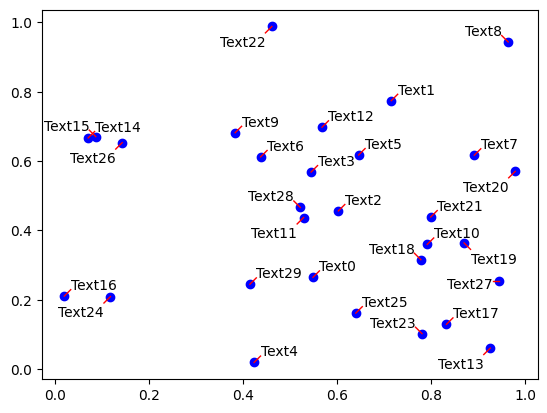

In [2]:
import textalloc as ta
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
x, y = np.random.random((2,30))
fig, ax = plt.subplots()
ax.scatter(x, y, c='b')
text_list = [f'Text{i}' for i in range(len(x))]
ta.allocate(ax,x,y,
            text_list,
            x_scatter=x, y_scatter=y,
            textsize=10)
plt.show()

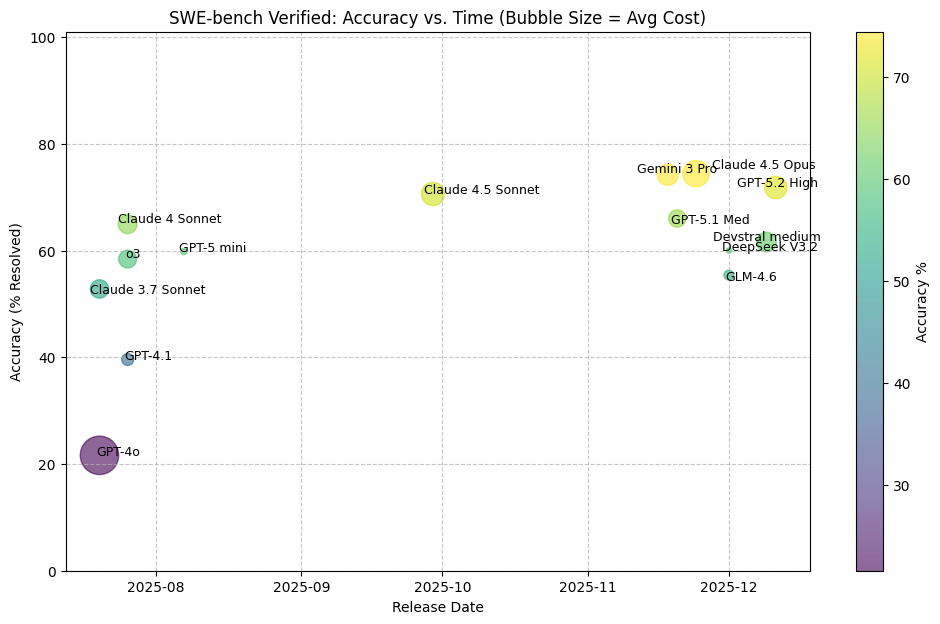

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from adjustText import adjust_text
import textalloc as ta

# Data setup
data = {
    "Model": [
        "Claude 4.5 Opus",
        "Gemini 3 Pro",
        "GPT-5.2 High",
        "Claude 4.5 Sonnet",
        "GPT-5.1 Med",
        "Claude 4 Sonnet",
        "DeepSeek V3.2",
        "GPT-5 mini",
        "o3",
        "GLM-4.6",
        "Claude 3.7 Sonnet",
        "GPT-4.1",
        "GPT-4o",
        "Devstral medium"
    ],
    "Date": pd.to_datetime(
        [
            "2025-11-24",
            "2025-11-18",
            "2025-12-11",
            "2025-09-29",
            "2025-11-20",
            "2025-07-26",
            "2025-12-01",
            "2025-08-07",
            "2025-07-26",
            "2025-12-01",
            "2025-07-20",
            "2025-07-26",
            "2025-07-20",
            "2025-12-09",
        ]
    ),
    "Accuracy": [
        74.40,
        74.20,
        71.80,
        70.60,
        66.00,
        64.93,
        60.00,
        59.80,
        58.40,
        55.40,
        52.80,
        39.58,
        21.62,
        61.60,
    ],
    "AvgCost": [
        0.72,
        0.46,
        0.52,
        0.56,
        0.31,
        0.37,
        0.03,
        0.04,
        0.33,
        0.10,
        0.35,
        0.15,
        1.53,
        0.40
    ],
}

df = pd.DataFrame(data)

# Create Plot
plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    df["Date"],
    df["Accuracy"],
    s=df["AvgCost"] * 500,
    alpha=0.6,
    c=df["Accuracy"],
    cmap="viridis",
)

# Add labels
# Create annotations
texts = []
ax = plt.gca()
for i, txt in enumerate(df["Model"]):
    texts.append(
        ax.text(
            df["Date"][i],
            df["Accuracy"][i],
            txt,
            fontsize=9,
        )
    )

# Adjust text positions to avoid overlap
adjust_text(texts)

ax = plt.gca()
# ta.allocate(
#     ax,
#     df["Date"].tolist(),
#     df["Accuracy"].tolist(),
#     df["Model"].tolist(),
# )

plt.title("SWE-bench Verified: Accuracy vs. Time (Bubble Size = Avg Cost)")
plt.xlabel("Release Date")
plt.ylabel("Accuracy (% Resolved)")
plt.ylim(0, 101)
plt.grid(True, linestyle="--", alpha=0.7)
plt.colorbar(scatter, label="Accuracy %")
plt.show()

In [2]:
pd.DataFrame(data).to_markdown()

'|    | Model             | Date                |   Accuracy |   AvgCost |\n|---:|:------------------|:--------------------|-----------:|----------:|\n|  0 | Claude 4.5 Opus   | 2025-11-24 00:00:00 |      74.4  |      0.72 |\n|  1 | Gemini 3 Pro      | 2025-11-18 00:00:00 |      74.2  |      0.46 |\n|  2 | GPT-5.2 High      | 2025-12-11 00:00:00 |      71.8  |      0.52 |\n|  3 | Claude 4.5 Sonnet | 2025-09-29 00:00:00 |      70.6  |      0.56 |\n|  4 | GPT-5.1 Med       | 2025-11-20 00:00:00 |      66    |      0.31 |\n|  5 | Claude 4 Sonnet   | 2025-07-26 00:00:00 |      64.93 |      0.37 |\n|  6 | DeepSeek V3.2     | 2025-12-01 00:00:00 |      60    |      0.03 |\n|  7 | GPT-5 mini        | 2025-08-07 00:00:00 |      59.8  |      0.04 |\n|  8 | o3                | 2025-07-26 00:00:00 |      58.4  |      0.33 |\n|  9 | GLM-4.6           | 2025-12-01 00:00:00 |      55.4  |      0.1  |\n| 10 | Claude 3.7 Sonnet | 2025-07-20 00:00:00 |      52.8  |      0.35 |\n| 11 | GPT-4.1          